In [2]:
import os
import shutil
import numpy as np
import sys
# from utils import setup_latex_environment
# setup_latex_environment()
import matplotlib
import pandas as pd
import seaborn as sns
import io
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tueplots import bundles
plt.style.use(bundles.icml2022())
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amsfonts}"
})
%matplotlib inline

/tmp/ipykernel_2234589/1161980668.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


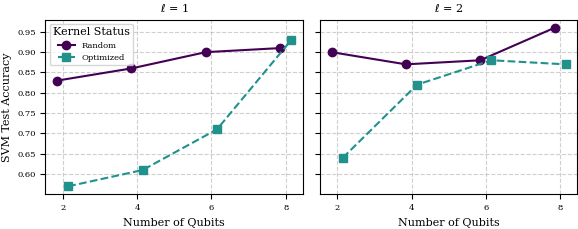

In [2]:
df = pd.read_csv("../results/mnist_chebyshev/results.csv")

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)
layers = [1, 2]
dodge_offset = 0.15  # How much to shift points left/right

# 3. Loop through layers to create each plot
for i, n_layer in enumerate(layers):
    ax = axes[i]
    # Filter data for the specific number of layers
    df_layer = df[df['n_layers'] == n_layer].sort_values('n_qubits')
    
    # Split between Learnt and Not Learnt
    learnt = df_layer[df_layer['train_kernel'] == True]
    not_learnt = df_layer[df_layer['train_kernel'] == False]
    
    # Plot "Not Learnt" (Fixed)
    ax.plot(not_learnt['n_qubits'] - dodge_offset, not_learnt['test_accuracy'], 
            marker='o', linestyle='-', color='#440154', label='Random')
    
    # Plot "Learnt" (Optimized)
    ax.plot(learnt['n_qubits'] + dodge_offset, learnt['test_accuracy'], 
            marker='s', linestyle='--', color='#21918c', label='Optimized')
    
    # Formatting
    ax.set_title(f"$\ell$ = {n_layer}")
    ax.set_xlabel("Number of Qubits")
    ax.set_xticks(df['n_qubits'].unique())
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i == 0:
        ax.set_ylabel("SVM Test Accuracy")
    
    # Show legend only on the first plot to avoid clutter
    if i == 0:
        ax.legend(title="Kernel Status")

plt.tight_layout()
plt.show()

/tmp/ipykernel_904876/1315702055.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


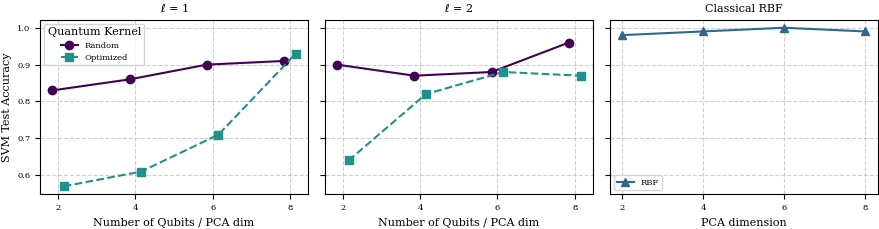

In [4]:
# Read separate result files
df_q = pd.read_csv("../results/mnist_chebyshev/results.csv")
df_rbf = pd.read_csv("../results/mnist_rbf/results.csv")

# Keep only relevant rows, in case files contain mixed results
df_q = df_q[df_q["kernel_type"] == "quantum_chebyshev"].copy()
df_rbf = df_rbf[df_rbf["kernel_type"] == "classical_rbf"].copy()

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5), sharey=True)

layers = [1, 2]
dodge_offset = 0.15

all_qubits = sorted(
    pd.concat([df_q["n_qubits"], df_rbf["n_qubits"]])
    .dropna()
    .unique()
)

# Quantum Chebyshev subplots
for i, n_layer in enumerate(layers):
    ax = axes[i]

    df_layer = df_q[df_q["n_layers"] == n_layer].sort_values("n_qubits")

    learnt = df_layer[df_layer["train_kernel"] == True]
    not_learnt = df_layer[df_layer["train_kernel"] == False]

    ax.plot(
        not_learnt["n_qubits"] - dodge_offset,
        not_learnt["test_accuracy"],
        marker="o",
        linestyle="-",
        color="#440154",
        label="Random",
    )

    ax.plot(
        learnt["n_qubits"] + dodge_offset,
        learnt["test_accuracy"],
        marker="s",
        linestyle="--",
        color="#21918c",
        label="Optimized",
    )

    ax.set_title(f"$\\ell$ = {n_layer}")
    ax.set_xlabel("Number of Qubits / PCA dim")
    ax.set_xticks(all_qubits)
    ax.grid(True, linestyle="--", alpha=0.6)

    if i == 0:
        ax.set_ylabel("SVM Test Accuracy")
        ax.legend(title="Quantum Kernel")

# Classical RBF subplot
ax = axes[2]
df_rbf = df_rbf.sort_values("n_qubits")

ax.plot(
    df_rbf["n_qubits"],
    df_rbf["test_accuracy"],
    marker="^",
    linestyle="-",
    color="#31688e",
    label="RBF",
)

ax.set_title("Classical RBF")
ax.set_xlabel("PCA dimension")
ax.set_xticks(all_qubits)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()

We evaluate the Chebyshev-inspired quantum kernel on a binary classification task using an SVM with a precomputed quantum kernel matrix. The input dimension is matched to the number of qubits by projecting the data onto $n_q$ features. We compare randomly initialized quantum kernels against optimized quantum kernels for different numbers of qubits and circuit depths.

The results show that increasing the number of qubits generally improves test accuracy, indicating that larger quantum feature spaces provide more expressive embeddings for the SVM classifier. Interestingly, randomly initialized quantum kernels already achieve strong performance, particularly for two-layer circuits, reaching a test accuracy of $0.96$ with $8$ qubits. Optimizing the kernel parameters improves performance in some regimes, especially for the one-layer circuit at larger qubit counts, but it does not consistently outperform the random kernel. This suggests that the Chebyshev feature map itself provides a strong inductive bias, while the current optimization procedure may require further tuning or a better alignment objective.

/tmp/ipykernel_1000048/2173038878.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


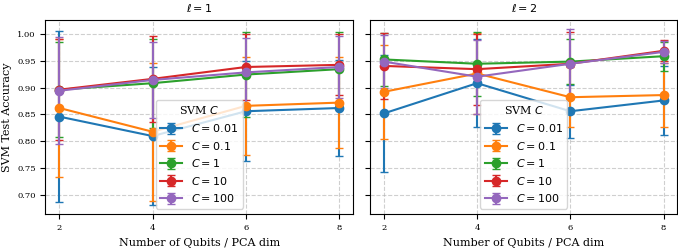

In [3]:
# Read results from the random-kernel sweep
df = pd.read_csv("../results/mnist_chebyshev_random_sweep/results.csv")

# Keep only random quantum Chebyshev results
df = df[
    (df["kernel_type"] == "quantum_chebyshev") &
    (df["train_kernel"] == False)
].copy()

# Make sure columns have the right type
df["n_layers"] = df["n_layers"].astype(int)
df["n_qubits"] = df["n_qubits"].astype(int)
df["svm_c"] = df["svm_c"].astype(float)

# Average over seeds
df_mean = (
    df.groupby(["n_layers", "n_qubits", "svm_c"], as_index=False)
      .agg(
          mean_accuracy=("test_accuracy", "mean"),
          std_accuracy=("test_accuracy", "std"),
      )
)

layers = sorted(df_mean["n_layers"].unique())
c_values = sorted(df_mean["svm_c"].unique())
all_qubits = sorted(df_mean["n_qubits"].unique())

fig, axes = plt.subplots(1, len(layers), figsize=(7, 2.7), sharey=True)

if len(layers) == 1:
    axes = [axes]

for i, n_layer in enumerate(layers):
    ax = axes[i]

    df_layer = df_mean[df_mean["n_layers"] == n_layer]

    for C in c_values:
        df_c = df_layer[df_layer["svm_c"] == C].sort_values("n_qubits")

        ax.errorbar(
            df_c["n_qubits"],
            df_c["mean_accuracy"],
            yerr=df_c["std_accuracy"],
            marker="o",
            linestyle="-",
            capsize=3,
            label=f"$C={C:g}$",
        )

    ax.set_title(f"$\\ell = {n_layer}$")
    ax.set_xlabel("Number of Qubits / PCA dim")
    ax.set_xticks(all_qubits)
    ax.grid(True, linestyle="--", alpha=0.6)

    if i == 0:
        ax.set_ylabel("SVM Test Accuracy")

    ax.legend(title="SVM $C$", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

The observed improvement with increasing $n_q$ suggests that the Chebyshev feature map provides a progressively richer representation of the input data. However, this does not by itself establish a quantum advantage, since increasing $n_q$ also increases the number of retained PCA components. Therefore, the gain reflects both access to a larger classical input representation and a higher-dimensional quantum feature space.

These results show that the apparent performance of the quantum kernel depends not only on the feature map architecture, but also on the downstream SVM regularization. Once $C$ is tuned, the random Chebyshev kernel reaches competitive accuracy, with the best configurations approaching $95{-}97\%$ test accuracy.